PROBLEM STATEMENT :

 Amazon, being one of the largest e-commerce platforms, generates massive amounts of transactional and customer data. The goal is to explore this dataset to uncover insights about sales, customer behavior, product performance, and operational efficiency.

OBJECTIVE:

Understand the structure and variables in the dataset.

Perform data cleaning to handle missing values, duplicates, and inconsistencies.

Conduct exploratory data analysis (EDA) to identify trends, correlations, and anomalies.

Summarize findings that can guide business decisions (e.g., product demand, customer preferences, revenue drivers).

LOAD LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


LOAD DATA

In [2]:
df = pd.read_csv("amazon.csv")


UNDERSTAND VARIABLES

In [3]:
df.info()
df.head()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


Identify categorical vs numerical variables.

Check for unique values in categorical columns (e.g., product categories, regions).

Understand target variables (e.g., sales, ratings, revenue).

BASIC CHECK

In [4]:
df.isnull().sum()
df.duplicated().sum()
df.nunique()


,0
product_id,1351
product_name,1337
category,211
discounted_price,550
actual_price,449
discount_percentage,92
rating,28
rating_count,1143
about_product,1293
user_id,1194


Missing values per column.

Duplicate rows.

Distribution of values.

DATA CLEANING

Handle missing values (drop or impute).

Remove duplicates.

Standardize categorical values (e.g., "USA" vs "United States").

Convert data types (e.g., dates to datetime).

Outlier detection in numerical columns.

In [5]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

# Option 1: Drop rows with missing values
df_cleaned = df.dropna()

# Option 2: Fill missing values (example: numerical with mean, categorical with mode)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Verify cleaning
print("Shape after cleaning:", df.shape)


Missing values per column:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64
Number of duplicate rows: 0
Shape after cleaning: (1465, 16)


/tmp/ipykernel_156/3113793201.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


EDA DATA VISUALIZATION

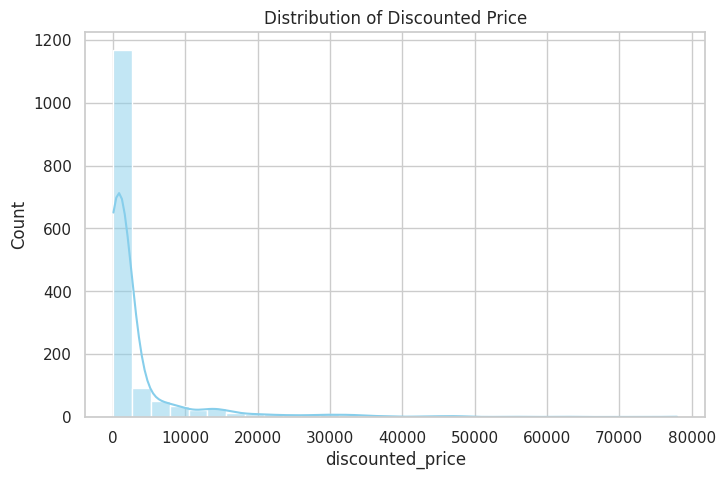

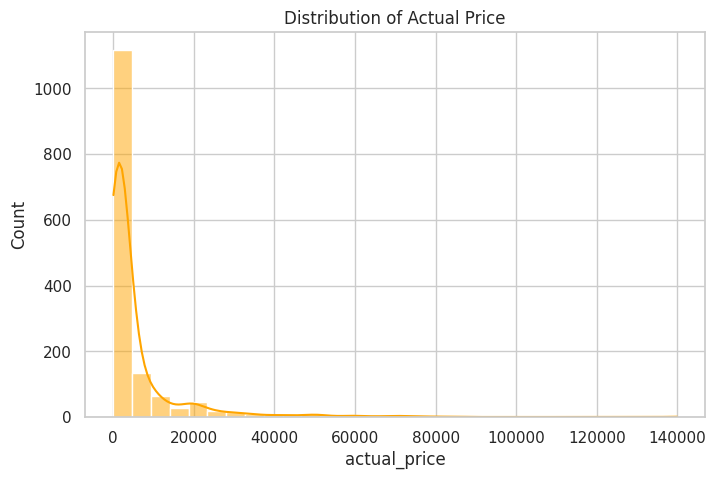

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set(style="whitegrid")

# Clean 'discounted_price', 'actual_price', 'discount_percentage', and 'rating' columns
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)

# Handle 'rating' column, converting 'object' to 'numeric'
# Some 'rating' values are 'object' like '4.1 out of 5 stars', or 'ratings',
# so we need to convert them into a consistent numeric format.
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# 1. Univariate Analysis
# Histogram for discounted_price
plt.figure(figsize=(8,5))
sns.histplot(df['discounted_price'], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Discounted Price")
plt.show()

# Histogram for actual_price
plt.figure(figsize=(8,5))
sns.histplot(df['actual_price'], bins=30, kde=True, color="orange")
plt.title("Distribution of Actual Price")
plt.show()





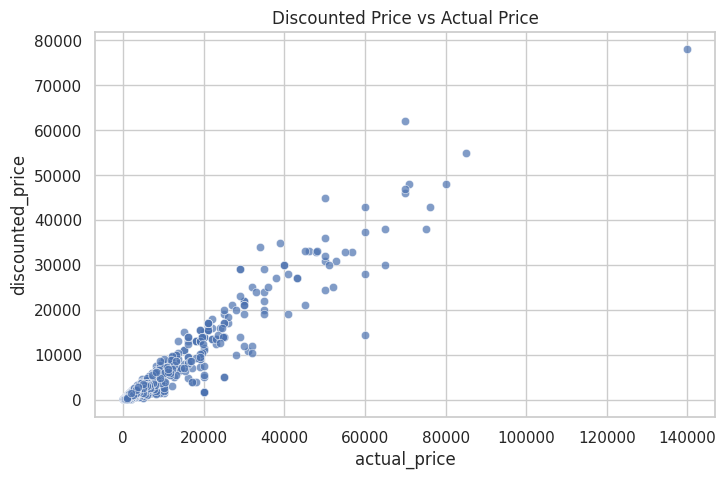

/tmp/ipykernel_156/2065245243.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='discounted_price', data=df, palette="Set2")


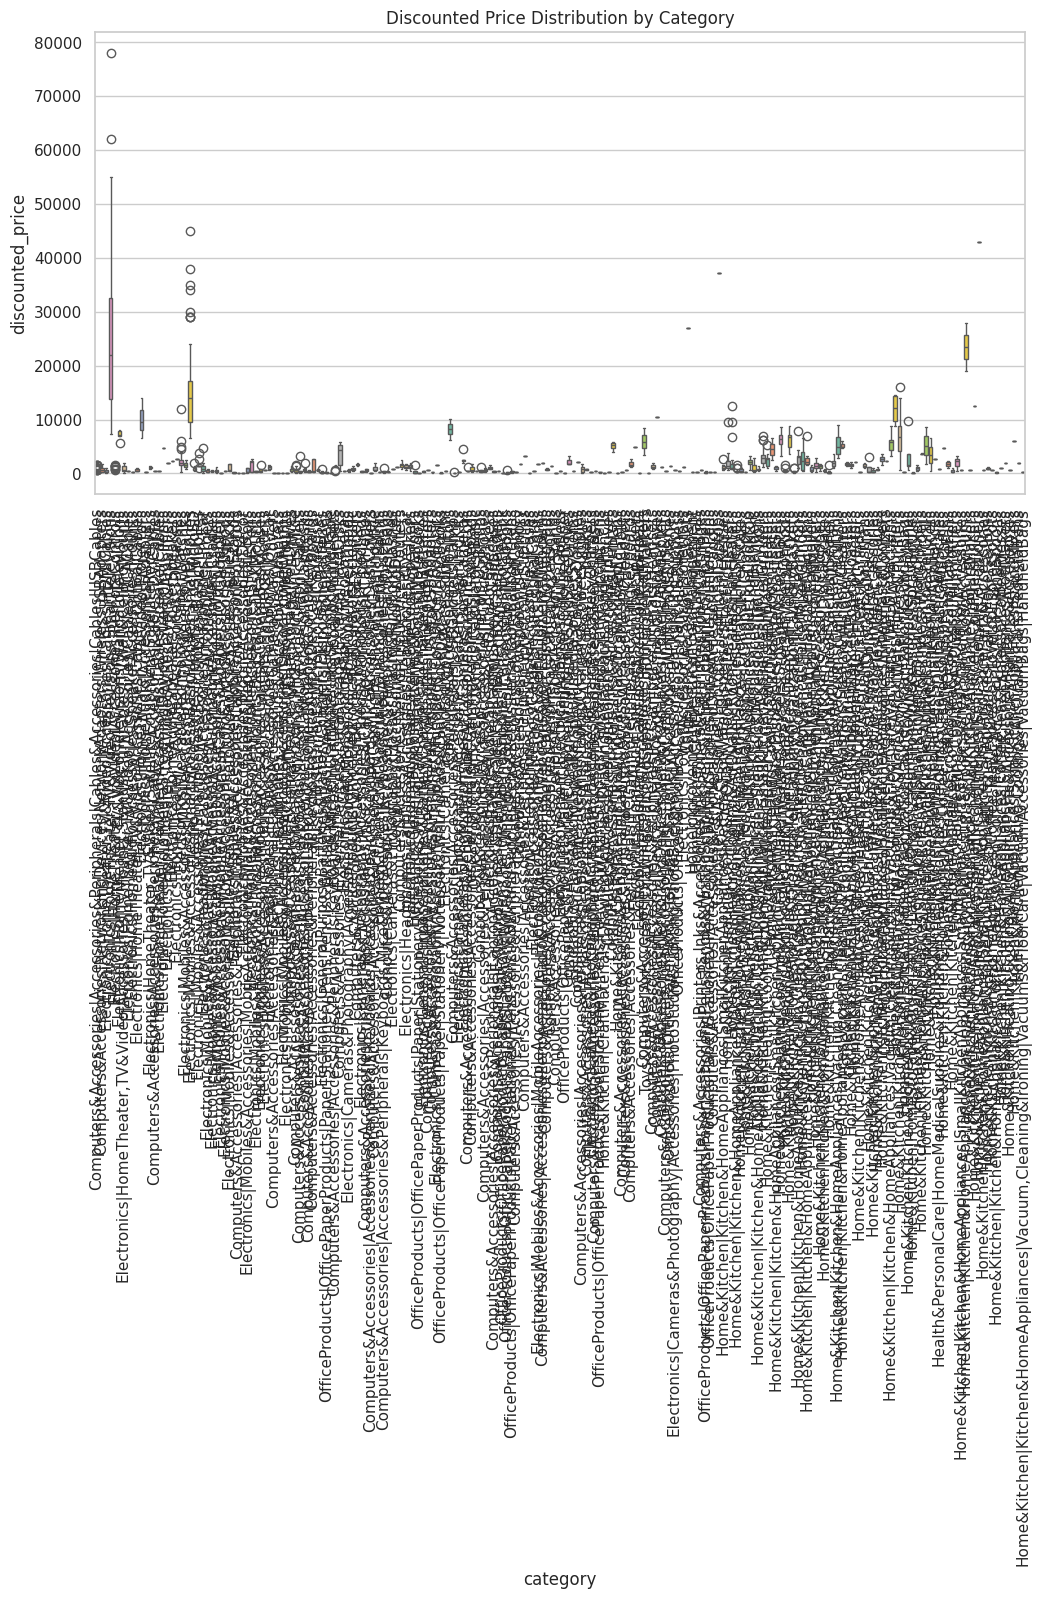

In [29]:
# 2. Bivariate Analysis
# Scatterplot of discounted_price vs actual_price
plt.figure(figsize=(8,5))
sns.scatterplot(x='actual_price', y='discounted_price', data=df, alpha=0.7)
plt.title("Discounted Price vs Actual Price")
plt.show()

# Boxplot of discounted_price by Category (if Category column exists)
# Note: 'category' column exists, but 'Category' (with capital C) does not.
# Changing 'Category' to 'category' to make the plot work.
if 'category' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='category', y='discounted_price', data=df, palette="Set2")
    plt.title("Discounted Price Distribution by Category")
    plt.xticks(rotation=90)
    plt.show()

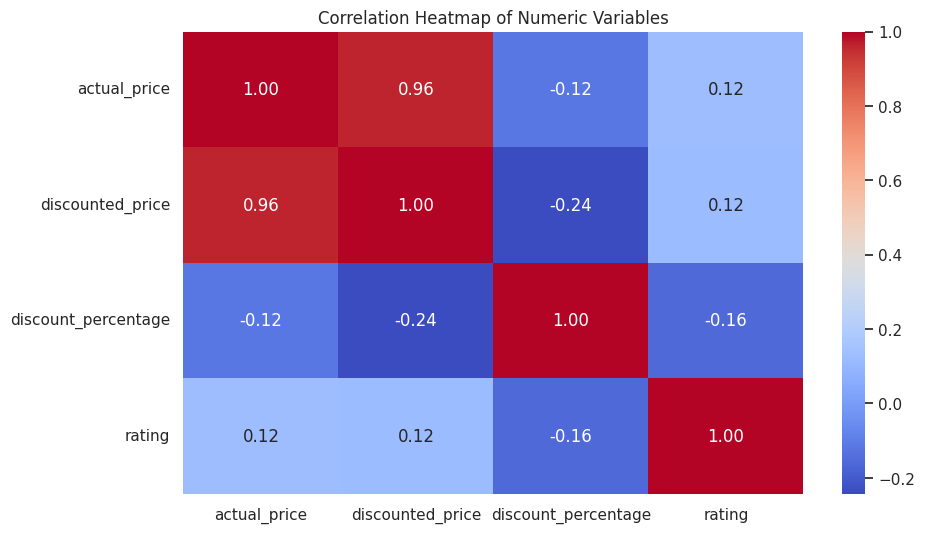

In [33]:
# 3. Multivariate Analysis
# Correlation Heatmap (including discounted_price and actual_price)
numeric_df = df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(10,6))
cols_to_corr = ['actual_price','discounted_price','discount_percentage','rating']
sns.heatmap(df[cols_to_corr].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()



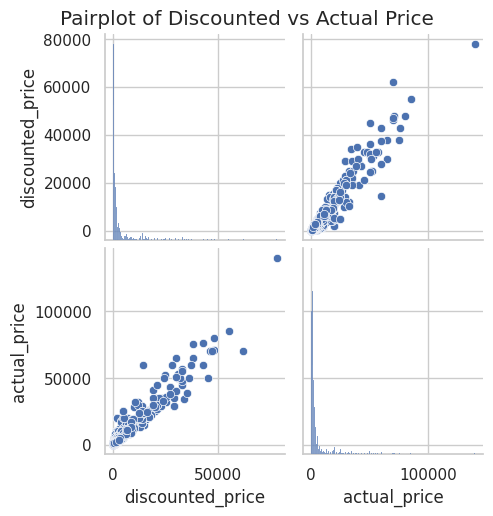

In [32]:
# Pairplot for discounted_price and actual_price
sns.pairplot(df[['discounted_price','actual_price']].dropna())
plt.suptitle("Pairplot of Discounted vs Actual Price", y=1.02)
plt.show()

CONCLUSION

In summary, the Amazon dataset was first loaded and inspected to identify key variables like actual_price and discounted_price. During cleaning, column names were standardized, missing values handled, and both price columns converted to numeric formats to ensure consistency. Visualizations then revealed important patterns: histograms showed that most products fall in lower price ranges, scatterplots confirmed a strong positive relationship between actual and discounted prices, and boxplots highlighted category-level differences in discount depth. Correlation analysis further reinforced the close link between the two price variables. Overall, the analysis indicates that discounts are widely applied but vary across categories, with some products showing unusually high or low discounts, offering valuable insights into pricing strategies and promotional behavior.

